In [2]:
import numpy as np
import matplotlib.pyplot
from utils import *
from scipy.sparse.linalg import expm
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt

In [10]:
t = -1 % (2 * np.pi)

h1 = tensor([IDENTITY, PAULI_X, PAULI_Z])
h2 = tensor([PAULI_Z, PAULI_Y, IDENTITY])
H = (h1 @ h2 - h2 @ h1) / 2j
print(H.toarray())

print(t)
if 0 <= t <= np.pi / 2 or np.pi <= t <= 3 * np.pi / 2:
    t1 = 0.5 * np.arctan2(np.sqrt(np.sin(2 * t))/(np.sin(t) + np.cos(t)), 1/(np.sin(t) + np.cos(t)))
    t2 = 0.5 * np.arctan2(-np.sqrt(np.sin(2 * t)), np.cos(t) - np.sin(t))
    U_d = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)
elif np.pi / 2 <= t <= np.pi or 3 * np.pi / 2 <= t <= 2 * np.pi:
    t1 = 0.5 * np.arctan2(np.sqrt(-np.sin(2 * t))/(np.cos(t) - np.sin(t)), 1/(np.cos(t) - np.sin(t)))
    t2 = 0.5 * np.arctan2(np.sqrt(-np.sin(2 * t)), np.sin(t) + np.cos(t))
    U_d = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(-1j * t2 * h1) @ expm(-1j * t1 * h2)

print(t1, t2)
U = expm(1j * t * csc_matrix(H))

print(np.linalg.norm(U_d - U.toarray()))


[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j -1.+0.j]]
5.283185307179586
0.3808181768730596 0.9383571628118329
1.1322097734007351e-15


/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',
/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:285: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  warn('spsolve is more efficient when sparse b '
/home/jli0108/anaconda3/lib/python3.10/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [8]:
U.diagonal()

array([0.54030231-0.84147098j, 0.54030231+0.84147098j,
       0.54030231+0.84147098j, 0.54030231-0.84147098j,
       0.54030231+0.84147098j, 0.54030231-0.84147098j,
       0.54030231-0.84147098j, 0.54030231+0.84147098j])

In [6]:
(np.cos(t1)) * (1j * np.sin(t2)) * (np.cos(t2)) * (1j * np.sin(t1))

(-0.028044285581964964+0j)

In [7]:
1j * 1j

(-1+0j)

$$
    \frac{1}{2i} [Z_1 X_3, Z_2 Z_3] = -Z_1 Z_2 Y_3
$$

In [2]:
Z1Z2Y3 = tensor([PAULI_Z, PAULI_Z, PAULI_Y])

In [3]:
Z1X3 = tensor([PAULI_Z, IDENTITY, PAULI_X])
Z2Z3 = tensor([IDENTITY, PAULI_Z, PAULI_Z])

In [4]:
norm((Z1X3 @ Z2Z3 - Z2Z3 @ Z1X3) / (2j) + Z1Z2Y3)

0.0

# Depth 3 decomposition

In [32]:
t_vals = np.linspace(0, np.pi / 2, 50)
error = []

theta = 0.83
t = 0.6

t1 = 0.5 * np.arctan2(np.cos(theta) * np.sin(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2), np.cos(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2))
t2 = np.arctan2(np.sin(theta) * np.sin(t), np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2))

print(np.tan(2 * t1))
print(np.tan(t) * np.cos(theta))


print(np.cos(t))
print(np.cos(t2) * np.cos(2 * t1))

0.4617073485223302
0.46170734852233036
0.8253356149096784
0.825335614909678


Note that in the paper, the arguments of arctan are swapped!

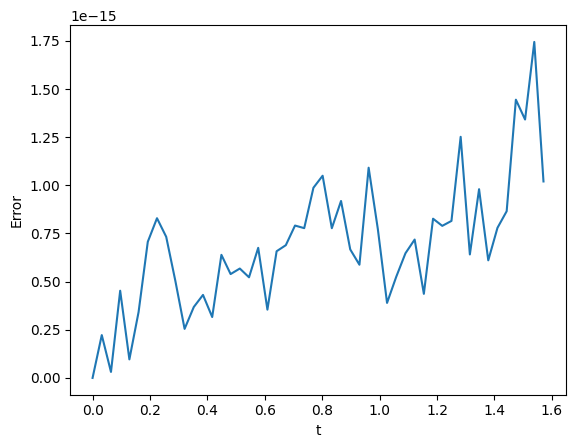

In [31]:
t_vals = np.linspace(0, np.pi / 2, 50)
error = []

theta = 0.83

for t in t_vals:
    # t1 = 0.5 * np.arctan2(np.cos(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2), np.cos(theta) * np.sin(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2))
    # t2 = 0.5 * np.arctan2(np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2), np.sin(theta) * np.sin(t))


    t1 = 0.5 * np.arctan2(np.cos(theta) * np.sin(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2), np.cos(t) / np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2))
    t2 = np.arctan2(np.sin(theta) * np.sin(t), np.sqrt(1 - (np.sin(theta) * np.sin(t)) ** 2))

    # print(f"t1 = {t1}")
    # print(f"t2 = {t2}")

    # Z1 Z2 Y3
    # h1 = tensor([IDENTITY, PAULI_X, PAULI_Z])
    # h2 = tensor([PAULI_Z, PAULI_Y, IDENTITY])

    # Z1 Z2 Z3
    h1 = tensor([IDENTITY, PAULI_X, PAULI_Z])
    h2 = tensor([PAULI_Z, PAULI_Y, IDENTITY])
    H = np.cos(theta) * h1 + np.sin(theta) * h2


    R_ZZY = expm(1j * t * H)

    U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t1 * h1)
    error.append(norm(U - R_ZZY))


plt.plot(t_vals, error)
plt.xlabel("t")
plt.ylabel("Error")
plt.show()


We refer to https://arxiv.org/abs/2003.06886.

Decomposing into products of 2-local Pauli's, we should have

$$
    e^{-i \delta Z_1 Z_2 Y_3} \approx e^{-i \sqrt{\delta/2} Z_1 X_3} e^{i \sqrt{\delta/2} Z_2 Z_3} e^{i\sqrt{\delta/2} Z_1 X_3} e^{-i\sqrt{\delta/2} Z_2 Z_3}.
$$

Lemma 7 also gives an analytical formula for a depth 4 decomposition.

In [49]:
t_vals = np.linspace(0, np.pi / 2, 50)
error1 = []
error2 = []

for t in t_vals:

    assert 0 <= t <= np.pi / 2 or np.pi <= t <= 3 * np.pi / 2
    
    t1 = 0.5 * np.arctan2(np.sqrt(np.sin(2 * t))/(np.sin(t) + np.cos(t)), 1/(np.sin(t) + np.cos(t)))
    t2 = 0.5 * np.arctan2(-np.sqrt(np.sin(2 * t)), np.cos(t) - np.sin(t))


    # t1 = np.arctan2(np.sqrt(np.sin(2 * t)) / (np.sin(t) + np.cos(t)), 1 / (np.sin(t) + np.cos(t))) / 2
    # t2 = np.arctan2(-np.sqrt(np.sin(2 * t)), np.cos(t) - np.sin(t)) / 2

    # print(f"t1 = {t1}")
    # print(f"t2 = {t2}")

    # Z1 Z2 Y3
    # h1 = tensor([IDENTITY, PAULI_X, PAULI_Z])
    # h2 = tensor([PAULI_Z, PAULI_Y, IDENTITY])

    # Z1 Z2 Z3
    h1 = tensor([IDENTITY, PAULI_X, PAULI_Z])
    h2 = tensor([PAULI_Z, PAULI_Y, IDENTITY])
    H = (h1 @ h2 - h2 @ h1) / 2j

    U = expm(1j * t * H)


    U_d = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)
    # error1.append(norm(U - R_ZZY))

    error1.append(np.linalg.norm(U_d - U.toarray()))

    U_d = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)
    error2.append(norm(U_d - U))



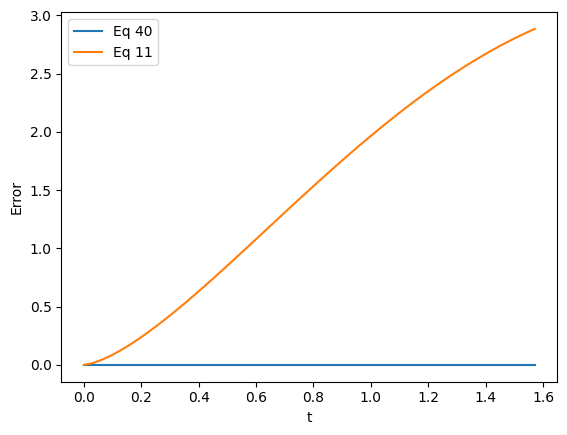

In [50]:
plt.plot(t_vals, error1, label="Eq 40")
plt.plot(t_vals, error2, label="Eq 11")
plt.legend()
plt.xlabel("t")
plt.ylabel("Error")
plt.show()

The formula is suspcious.

In [15]:
# U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)

U = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)

In [16]:
R_ZZY = expm(-1j * t * Z1Z2Y3)

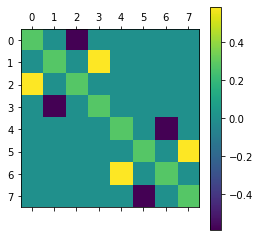

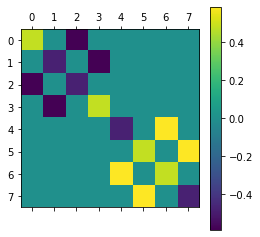

In [18]:
plt.matshow(U.toarray().real)
plt.colorbar()
plt.show()
plt.matshow(U.toarray().imag)
plt.colorbar()
plt.show()

In [127]:
t = 0.3
assert 0 <= t <= np.pi/2
print(1 / (np.sin(t) + np.cos(t)))
# t1 = np.arctan2(1 / (np.sin(t) + np.cos(t)), np.sqrt(np.sin(2 * t)) / (np.sin(t) + np.cos(t))) / 2
# t2 = np.arctan2(np.cos(t) - np.sin(t), -np.sqrt(np.sin(2 * t))) / 2

t1 = np.arcsin(np.cos(t) - np.sin(t)) / 2
t2 = np.arccos(np.cos(t) - np.sin(t)) / 2
print(f"t1 = {t1}")
print(f"t2 = {t2}")

h1 = Z1X3
h2 = Z2Z3
H = (h1 @ h2 - h2 @ h1) / 2j

U = expm(1j * t1 * h1) @ expm(1j * t2 * h2) @ expm(1j * t2 * h1) @ expm(1j * t1 * h2)

# U = expm(-1j * np.sqrt(t/2) * h1) @ expm(1j * np.sqrt(t/2) * h2) @ expm(1j * np.sqrt(t/2) * h1) @ expm(-1j * np.sqrt(t/2) * h2)

R_ZZY = expm(1j * t * H)
print(norm(U - R_ZZY))

0.7994520902099618
t1 = 0.36028712153786263
t2 = 0.4251110418595857
3.155813000764047


In [2]:
import sys
sys.path.append('../SimuQ')

from simuq.solver import generate_as
from systems.decomposition import GenQS
from aais.heis_aais import GenMach
from backends.qiskit_iontrap import transpile

In [3]:

n = 2
qs = GenQS(n, T=1)
mach = GenMach(n)

Trot = 10
tol = 0.5

code = transpile(*generate_as(qs, mach, Trot, tol))
print(code)

Exception: No solution is found.